# Домашнее задание 

В этом задании мы попрактикуемся в методах снижения размерности и кластеризации данных. 

Мы будем работать с набором данных Samsung Human Activity Recognition. Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S3, также известен вид активности человека с телефоном в кармане – ходил ли он, стоял, лежал, сидел или шел вверх/вниз по лестнице.

Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [1]:
import numpy as np
import seaborn as sns
from sklearn.utils import resample

%matplotlib inline
from matplotlib import pyplot as plt
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn import metrics
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN, Birch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 17

In [2]:
X_train = np.loadtxt("samsung_train.txt")
y_train = np.loadtxt("samsung_train_labels.txt").astype(int)

X_test = np.loadtxt("samsung_test.txt")
y_test = np.loadtxt("samsung_test_labels.txt").astype(int)

Для кластеризации нам не нужен вектор ответов. Объедините обучающую и тестовую выборки.

In [3]:
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])

In [4]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

Эти метки соответствуют:

1 - ходьбе,
2 - подъему вверх по лестнице,
3 - спуску по лестнице,
4 - сидению,
5 - стоянию,
6 - лежанию

In [5]:
n_classes = len(np.unique(y))
RANDOM_STATE = 42

Отмасштабируйте выборку с помощью StandardScaler.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Понижаем размерность с помощью PCA, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии исходных (отмасштабированных) данных. Используйте отмасштабированную выборку и зафиксируйте random_state.

In [7]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"число компонент после PCA: {X_pca.shape[1]}")

число компонент после PCA: 65


Визуализируйте данные в проекции на первые две главные компоненты.

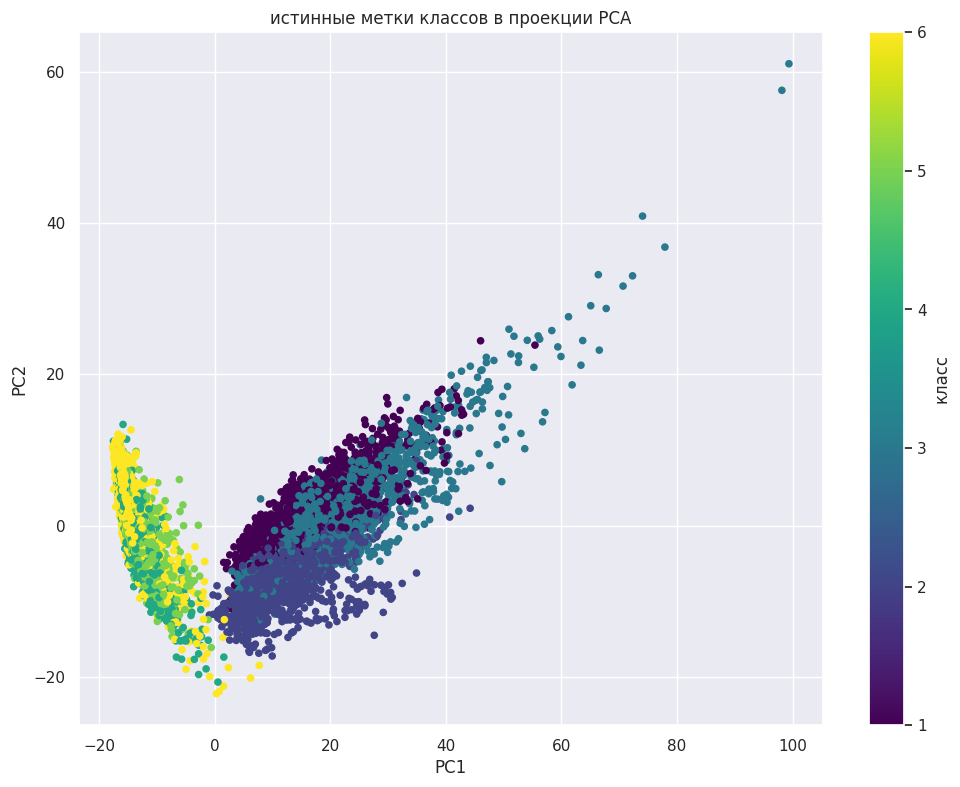

In [8]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='viridis')
plt.title("истинные метки классов в проекции PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="класс")
plt.show()

Сделайте кластеризацию данных методом KMeans, обучив модель на данных со сниженной за счет PCA размерностью. В данном случае нужно искать 6 кластеров (так как у нас 6 классов).

Параметры:

n_clusters = n_classes (число уникальных меток целевого класса)

n_init = 100

random_state = RANDOM_STATE (для воспроизводимости результата)

In [9]:
kmeans = KMeans(n_clusters=n_classes, n_init=100, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_pca)

Визуализируйте данные в проекции на первые две главные компоненты. Раскрасьте точки в соответствии с полученными метками кластеров.

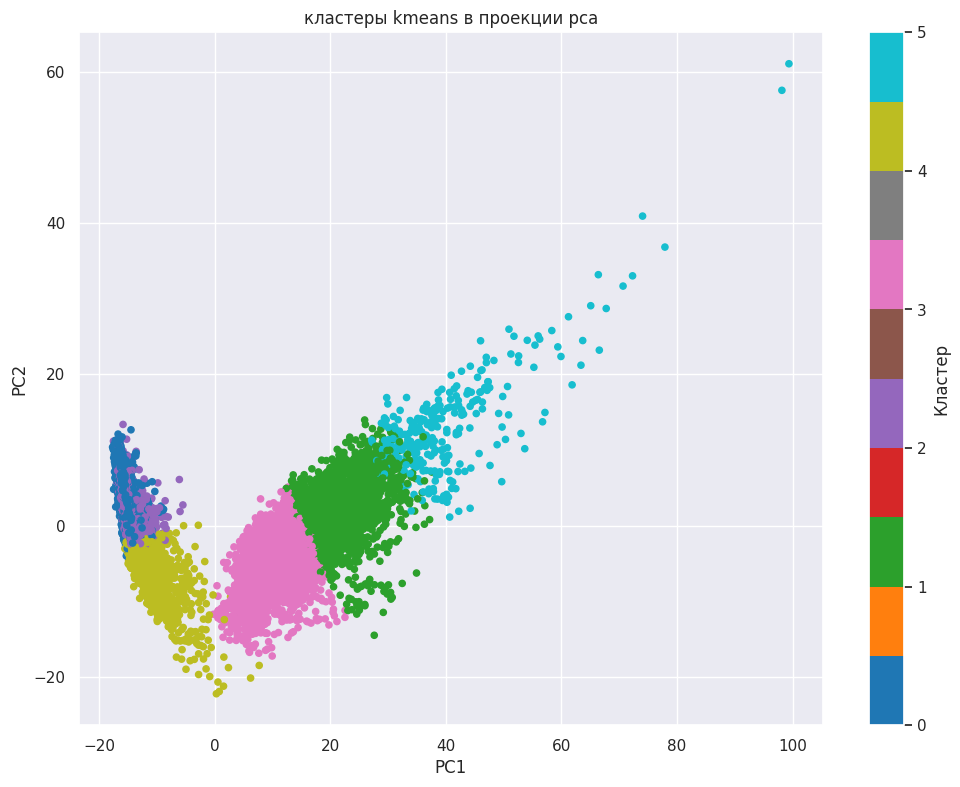

In [10]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, s=20, cmap='tab10')
plt.title("кластеры kmeans в проекции pca")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Кластер")
plt.show()

Выведите на экран значения метрик качества кластеризации

In [11]:
print("KMeans")
print("ARI:", metrics.adjusted_rand_score(y, kmeans_labels))
print("Homogeneity:", metrics.homogeneity_score(y, kmeans_labels))
print("Completeness:", metrics.completeness_score(y, kmeans_labels))
print("V-measure:", metrics.v_measure_score(y, kmeans_labels))

KMeans
ARI: 0.4194956465790897
Homogeneity: 0.5405702796626982
Completeness: 0.5809669531868589
V-measure: 0.5600410921019029


Теперь попробуем сделать кластеризацию с помощью AgglomerativeClustering (https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

In [12]:
ag = AgglomerativeClustering(n_clusters=n_classes, linkage='ward')
ag_labels = ag.fit_predict(X_pca)

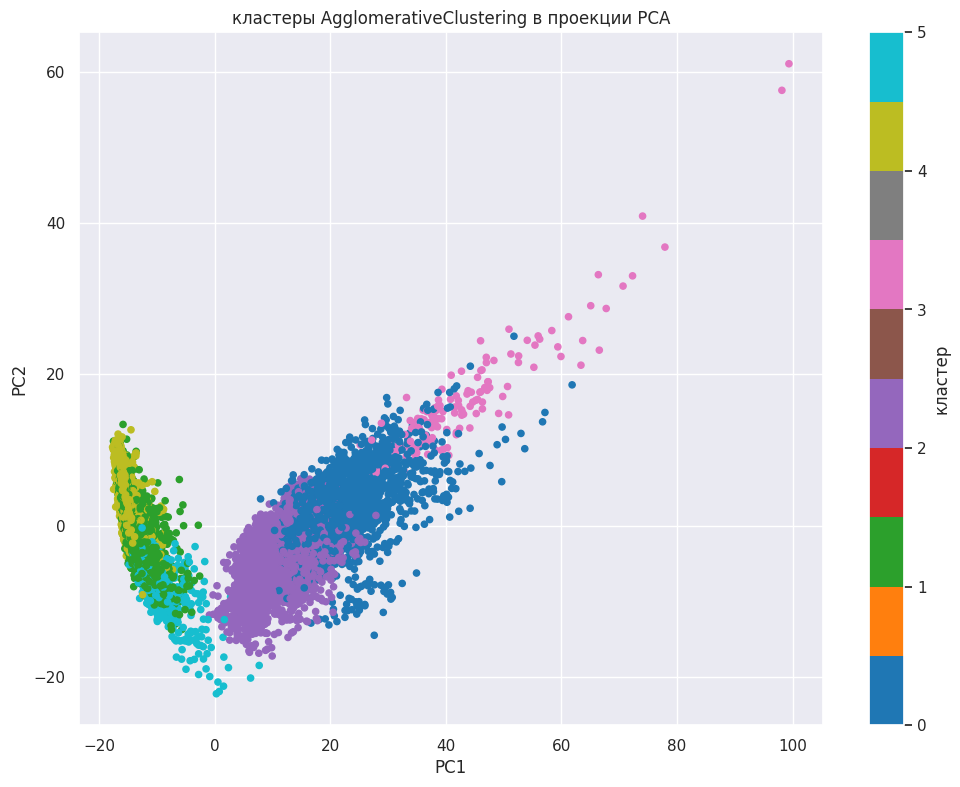

In [13]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=ag_labels, s=20, cmap='tab10')
plt.title("кластеры AgglomerativeClustering в проекции PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="кластер")
plt.show()

Выведите метрики качества для полученного разбиения на кластеры. Сравните с kmeans. Запишите выводы!

In [14]:
print("AgglomerativeClustering")
print("ARI:", metrics.adjusted_rand_score(y, ag_labels))
print("Homogeneity:", metrics.homogeneity_score(y, ag_labels))
print("Completeness:", metrics.completeness_score(y, ag_labels))
print("V-measure:", metrics.v_measure_score(y, ag_labels))

AgglomerativeClustering
ARI: 0.49362763373004886
Homogeneity: 0.5779071626156045
Completeness: 0.6728743591901729
V-measure: 0.6217855076000528


agglomerative показал лучшее качество кластеризации, чем kmeans — это прям видно по ari и v-measure

agglomerative удалось точнее выделить группы активности

Попробуйте применить другие методы кластеризации из sklearn. Также вычислите метрики качества и сделайте вывод о том, какой метод сработал лучше. 

Для самой успешной из полученных кластеризаций попробуйте дать интерпретацию кластеров. Опишите характеристики объектов, попавших в каждый кластер. Для этого можете ответить на следующие вопросы:

* похожи ли объекты внутри каждого кластера на определенный тип активности человека?
* в каких кластерах смешано несколько типов активности? С чем, на ваш взгляд, это может быть связано?
* качественная ли получилась кластеризация? На основании чего вы можете сделать такой вывод?

In [15]:
X_sample, y_sample = resample(X_pca, y, n_samples=300, random_state=RANDOM_STATE)

spec = SpectralClustering(n_clusters=n_classes, random_state=RANDOM_STATE, assign_labels='kmeans')
spec_labels = spec.fit_predict(X_sample)

print("SpectralClustering")
print("ARI:", metrics.adjusted_rand_score(y_sample, spec_labels))
print("Homogeneity:", metrics.homogeneity_score(y_sample, spec_labels))
print("Completeness:", metrics.completeness_score(y_sample, spec_labels))
print("V-measure:", metrics.v_measure_score(y_sample, spec_labels))

c:\Users\Anastasia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


SpectralClustering
ARI: 0.00201648971703793
Homogeneity: 0.01142431554880424
Completeness: 0.3011324548143712
V-measure: 0.02201348690535823


c:\Users\Anastasia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [16]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_sample)

print("\nDBSCAN")
print("ARI:", metrics.adjusted_rand_score(y_sample, dbscan_labels))
print("Homogeneity:", metrics.homogeneity_score(y_sample, dbscan_labels))
print("Completeness:", metrics.completeness_score(y_sample, dbscan_labels))
print("V-measure:", metrics.v_measure_score(y_sample, dbscan_labels))



DBSCAN
ARI: 0.0
Homogeneity: 0.0
Completeness: 1.0
V-measure: 0.0


In [17]:
birch = Birch(n_clusters=n_classes)
birch_labels = birch.fit_predict(X_sample)

print("\nBirch")
print("ARI:", metrics.adjusted_rand_score(y_sample, birch_labels))
print("Homogeneity:", metrics.homogeneity_score(y_sample, birch_labels))
print("Completeness:", metrics.completeness_score(y_sample, birch_labels))
print("V-measure:", metrics.v_measure_score(y_sample, birch_labels))



Birch
ARI: 0.3091373612477657
Homogeneity: 0.4111313740185077
Completeness: 0.5983374750220165
V-measure: 0.48737572925876577


### cравнение методов кластеризации

| метод              | ARI   | Homogeneity | Completeness | V-measure |
|--------------------|-------|-------------|--------------|-----------|
| **KMeans**         | 0.419 | 0.541       | 0.581        | 0.560     |
| **Agglomerative**  | 0.494 | 0.578       | 0.673        | 0.622     |
| **SpectralClustering** | 0.002 | 0.011   | 0.301        | 0.022     |
| **DBSCAN**         | 0.000 | 0.000       | 1.000        | 0.000     |
| **Birch**          | 0.309 | 0.411       | 0.598        | 0.487     |


самая успешная кластеризация по метрикам — это AgglomerativeClustering (V-measure = 0.622, ARI = 0.494)

1) похожи ли объекты внутри каждого кластера на определённый тип активности?

да, в целом внутри каждого видна однородность:

один кластер почти полностью состоит из ходьбы (1), другой — из сидения (4). есть кластер, характерный для стояния (5) и лежания (6), что как будто бы логично — эти типы активности близки по динамике сенсоров

2) в каких кластерах смешано несколько типов активности? с чем это может быть связано?

стояние, сидение, лежание — статичные активности, видимо, сенсоры плохо считывают разницу

иногда подъём по лестнице (2) и спуск (3) попадают в один кластер — возможно, из-за схожего паттерна движения?

3) качественная ли получилась кластеризация?

как будто да. во-первых, метрики: V-measure = 0.622, ARI = 0.494. во-вторых, визуализация показывает относительно чёткие группы. ну и в-третьих, видна разница между динамической и статической активностями